# Explore Synthetic Benchmark

Small notebook to inspect the aggregated synthetic benchmark dataset.

It covers:
- loading `data/mcq_synth_benchmark.jsonl`
- dataset size and split composition
- question template and answer distributions
- a few example rows
- listening to one example audio file


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display

DATASET_PATH = Path("../data/mcq_synth_benchmark.jsonl")
AUDIO_ROOT = Path("../data/audio")

assert DATASET_PATH.exists(), f"Missing dataset: {DATASET_PATH}"
assert AUDIO_ROOT.exists(), f"Missing audio root: {AUDIO_ROOT}"


In [2]:
rows = []
with DATASET_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(
    {
        "id": row["id"],
        "task_id": row["task_id"],
        "benchmark_family": row["benchmark_family"],
        "difficulty": row["difficulty"],
        "question_template": row["question_template"],
        "question": row["question"],
        "audio_filename": row["audio_filename"],
        "n_options": len(row["options"]),
        "answer_label": row["answer_label"],
        "answer_text": row["answer_text"],
        "source_task_id": row["source_task_id"],
    }
    for row in rows
)

print(f"rows: {len(df):,}")
print(f"task_id values: {sorted(df['task_id'].unique())}")
df.head()


rows: 6,000
task_id values: ['MCQ-SYNTH']


,id,task_id,benchmark_family,difficulty,question_template,question,audio_filename,n_options,answer_label,answer_text,source_task_id
0,synth_loudness_easy_000001,MCQ-SYNTH,loudness,easy,loudest,Which sound is the loudest?,synthetic/loudness/easy/synth_loudness_easy_00...,3,A,the third sound,MCQ-SYNTH-LOUDNESS
1,synth_loudness_easy_000002,MCQ-SYNTH,loudness,easy,quietest,Which sound is the quietest?,synthetic/loudness/easy/synth_loudness_easy_00...,3,A,the first sound,MCQ-SYNTH-LOUDNESS
2,synth_loudness_easy_000003,MCQ-SYNTH,loudness,easy,loudest,Which sound is the loudest?,synthetic/loudness/easy/synth_loudness_easy_00...,3,C,the third sound,MCQ-SYNTH-LOUDNESS
3,synth_loudness_easy_000004,MCQ-SYNTH,loudness,easy,quietest,Which sound is the quietest?,synthetic/loudness/easy/synth_loudness_easy_00...,3,A,the third sound,MCQ-SYNTH-LOUDNESS
4,synth_loudness_easy_000005,MCQ-SYNTH,loudness,easy,loudest,Which sound is the loudest?,synthetic/loudness/easy/synth_loudness_easy_00...,3,A,the first sound,MCQ-SYNTH-LOUDNESS


In [3]:
summary = {
    "by_family": df["benchmark_family"].value_counts().sort_index(),
    "by_difficulty": df["difficulty"].value_counts().sort_index(),
    "by_family_and_difficulty": pd.crosstab(df["benchmark_family"], df["difficulty"]),
    "by_template": df["question_template"].value_counts().sort_index(),
    "by_source_task": df["source_task_id"].value_counts().sort_index(),
}

for name, table in summary.items():
    print(f"\n{name}")
    display(table)



by_family


benchmark_family
loudness    1500
pitch       1500
rhythm      1500
time        1500
Name: count, dtype: int64


by_difficulty


difficulty
easy      2000
hard      2000
medium    2000
Name: count, dtype: int64


by_family_and_difficulty


difficulty,easy,hard,medium
benchmark_family,,,
loudness,500,500,500
pitch,500,500,500
rhythm,500,500,500
time,500,500,500



by_template


question_template
highest_pitch         750
longest_duration      375
loudest               750
lowest_pitch          750
more_beeps           1500
quietest              750
shortest_duration     375
starts_first          375
starts_last           375
Name: count, dtype: int64


by_source_task


source_task_id
MCQ-SYNTH-LOUDNESS    1500
MCQ-SYNTH-PITCH       1500
MCQ-SYNTH-RHYTHM      1500
MCQ-SYNTH-TIME        1500
Name: count, dtype: int64

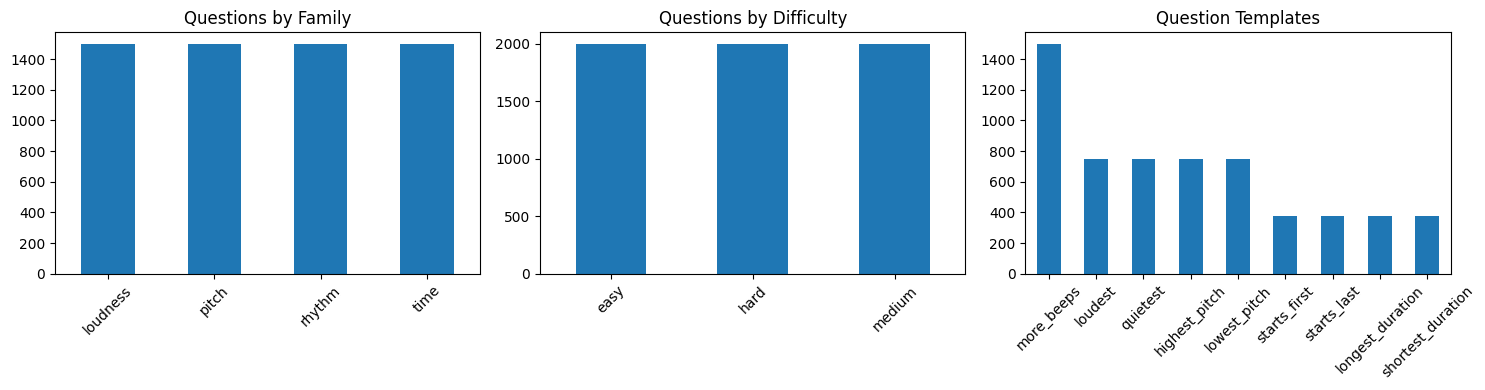

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["benchmark_family"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Questions by Family")
df["difficulty"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Questions by Difficulty")
df["question_template"].value_counts().sort_values(ascending=False).plot(kind="bar", ax=axes[2], title="Question Templates")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()


In [5]:
sample_cols = [
    "id",
    "benchmark_family",
    "difficulty",
    "question_template",
    "question",
    "answer_text",
    "audio_filename",
]

df.sample(10, random_state=7)[sample_cols].sort_values(["benchmark_family", "difficulty"])


,id,benchmark_family,difficulty,question_template,question,answer_text,audio_filename
179,synth_loudness_easy_000180,loudness,easy,quietest,Which sound is the quietest?,the first sound,synthetic/loudness/easy/synth_loudness_easy_00...
905,synth_loudness_hard_000406,loudness,hard,quietest,Which sound is the quietest?,the third sound,synthetic/loudness/hard/synth_loudness_hard_00...
1137,synth_loudness_medium_000138,loudness,medium,quietest,Which sound is the quietest?,the first sound,synthetic/loudness/medium/synth_loudness_mediu...
2352,synth_pitch_hard_000353,pitch,hard,highest_pitch,Which sound has the highest pitch?,the third sound,synthetic/pitch/hard/synth_pitch_hard_000353.wav
2043,synth_pitch_hard_000044,pitch,hard,lowest_pitch,Which sound has the lowest pitch?,the third sound,synthetic/pitch/hard/synth_pitch_hard_000044.wav
3346,synth_rhythm_easy_000347,rhythm,easy,more_beeps,Which burst contains more beeps?,the first burst,synthetic/rhythm/easy/synth_rhythm_easy_000347...
3279,synth_rhythm_easy_000280,rhythm,easy,more_beeps,Which burst contains more beeps?,the first burst,synthetic/rhythm/easy/synth_rhythm_easy_000280...
3675,synth_rhythm_hard_000176,rhythm,hard,more_beeps,Which burst contains more beeps?,the second burst,synthetic/rhythm/hard/synth_rhythm_hard_000176...
4320,synth_rhythm_medium_000321,rhythm,medium,more_beeps,Which burst contains more beeps?,the first burst,synthetic/rhythm/medium/synth_rhythm_medium_00...
5461,synth_time_hard_000462,time,hard,starts_last,Which sound starts last?,the square tone,synthetic/time/hard/synth_time_hard_000462.wav


In [6]:
example = rows[0]
audio_path = AUDIO_ROOT / example["audio_filename"]

print(json.dumps(example, indent=2)[:4000])
print(f"\naudio path: {audio_path}")
display(Audio(filename=str(audio_path)))


{
  "id": "synth_loudness_easy_000001",
  "task": "synthetic_mcq_benchmark",
  "task_id": "MCQ-SYNTH",
  "audio_filename": "synthetic/loudness/easy/synth_loudness_easy_000001.wav",
  "question": "Which sound is the loudest?",
  "options": [
    {
      "key": "third",
      "text": "the third sound",
      "type": "event",
      "label": "A"
    },
    {
      "key": "second",
      "text": "the second sound",
      "type": "event",
      "label": "B"
    },
    {
      "key": "first",
      "text": "the first sound",
      "type": "event",
      "label": "C"
    }
  ],
  "answer_label": "A",
  "answer_text": "the third sound",
  "benchmark_family": "loudness",
  "difficulty": "easy",
  "generator_version": "synth-v1",
  "question_template": "loudest",
  "scene": {
    "duration_seconds": 2.8,
    "events": [
      {
        "key": "first",
        "text": "the first sound",
        "waveform": "sine",
        "onset": 0.4,
        "duration": 0.4,
        "offset": 0.8,
        "pitch

In [10]:
random_samples = df.sample(10, random_state=42)

for _, row in random_samples.iterrows():
    print(f"id: {row['id']}")
    print(f"benchmark_family: {row['benchmark_family']}")
    print(f"difficulty: {row['difficulty']}")
    print(f"question_template: {row['question_template']}")
    print(f"question: {row['question']}")
    print(f"answer_text: {row['answer_text']}")
    print("\n")

    audio_path = AUDIO_ROOT / row["audio_filename"]
    display(Audio(filename=str(audio_path)))

    print("\n")

    print("-" * 100)
    print("\n")

    print("\n")

id: synth_pitch_easy_000283
benchmark_family: pitch
difficulty: easy
question_template: highest_pitch
question: Which sound has the highest pitch?
answer_text: the first sound






----------------------------------------------------------------------------------------------------




id: synth_rhythm_hard_000418
benchmark_family: rhythm
difficulty: hard
question_template: more_beeps
question: Which burst contains more beeps?
answer_text: the first burst






----------------------------------------------------------------------------------------------------




id: synth_loudness_easy_000222
benchmark_family: loudness
difficulty: easy
question_template: quietest
question: Which sound is the quietest?
answer_text: the third sound






----------------------------------------------------------------------------------------------------




id: synth_pitch_hard_000136
benchmark_family: pitch
difficulty: hard
question_template: lowest_pitch
question: Which sound has the lowest pitch?
answer_text: the second sound






----------------------------------------------------------------------------------------------------




id: synth_time_hard_000225
benchmark_family: time
difficulty: hard
question_template: starts_first
question: Which sound starts first?
answer_text: the square tone




...



----------------------------------------------------------------------------------------------------




id: synth_loudness_hard_000380
benchmark_family: loudness
difficulty: hard
question_template: quietest
question: Which sound is the quietest?
answer_text: the third sound






----------------------------------------------------------------------------------------------------




id: synth_loudness_easy_000157
benchmark_family: loudness
difficulty: easy
question_template: loudest
question: Which sound is the loudest?
answer_text: the first sound






----------------------------------------------------------------------------------------------------




id: synth_pitch_easy_000158
benchmark_family: pitch
difficulty: easy
question_template: lowest_pitch
question: Which sound has the lowest pitch?
answer_text: the second sound






----------------------------------------------------------------------------------------------------




id: synth_loudness_easy_000324
benchmark_family: loudness
difficulty: easy
question_template: quietest
question: Which sound is the quietest?
answer_text: the second sound






----------------------------------------------------------------------------------------------------




